# EDA corpus tin tức cho RAG
Phân tích chất lượng dữ liệu, độ dài, category, paragraph structure và áp lực chunking.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "Dataset" / "QA_Claude").exists():
    ROOT = ROOT.parent
if not (ROOT / "Dataset" / "QA_Claude").exists():
    raise FileNotFoundError(f"Không tìm thấy project root từ cwd: {Path.cwd()}")

DATA = ROOT / "Dataset" / "Create_QA_Vietonline" / "VietOnlineNews"
if not DATA.exists():
    DATA = ROOT / "Dataset" / "Create_QA_Vietonline" / "VietOnlineNews_CSV"

sns.set_theme(style="whitegrid")

parts = []
for split in ["train", "validation", "test"]:
    for name in [f"{split}_new.csv", f"{split}.csv"]:
        p = DATA / name
        if p.exists():
            x = pd.read_csv(p)
            x["split"] = split
            parts.append(x)
            break

if not parts:
    raise FileNotFoundError(f"Không tìm thấy file corpus CSV trong: {DATA}")

news = pd.concat(parts, ignore_index=True)

for c in ["id", "title", "description", "content", "category"]:
    if c not in news:
        news[c] = ""

news["content"] = news["content"].fillna("").astype(str)
news["content_chars"] = news["content"].str.len()
news["content_words"] = news["content"].str.split().str.len()
news["sentences"] = news["content"].str.count(r"[.!?]+")
news["paragraphs"] = news["content"].str.count(r"\s*") + 1
news["title_chars"] = news["title"].fillna("").astype(str).str.len()

for size in [256, 384, 512]:
    news[f"est_chunks_{size}"] = np.ceil(news["content_words"].clip(lower=1) / size).astype(int)

display(
    news.groupby("split")
    .agg(
        articles=("id", "size"),
        unique_ids=("id", "nunique"),
        avg_words=("content_words", "mean"),
        avg_paragraphs=("paragraphs", "mean"),
    )
    .round(2)
)


,articles,unique_ids,avg_words,avg_paragraphs
split,,,,
test,2000,2000,678.56,3118.54
train,10073,10073,685.76,3153.61
validation,2500,2500,679.65,3125.52


## Missing values, duplicates và mất cân bằng category

,null_rate,empty_rate
id,0.0,0.0
title,0.0,0.0
description,0.0,0.0
content,0.0,0.0
category,0.0,0.0
split,0.0,0.0
content_chars,0.0,0.0
content_words,0.0,0.0
sentences,0.0,0.0
paragraphs,0.0,0.0


Duplicate id: 0 | duplicate title: 2


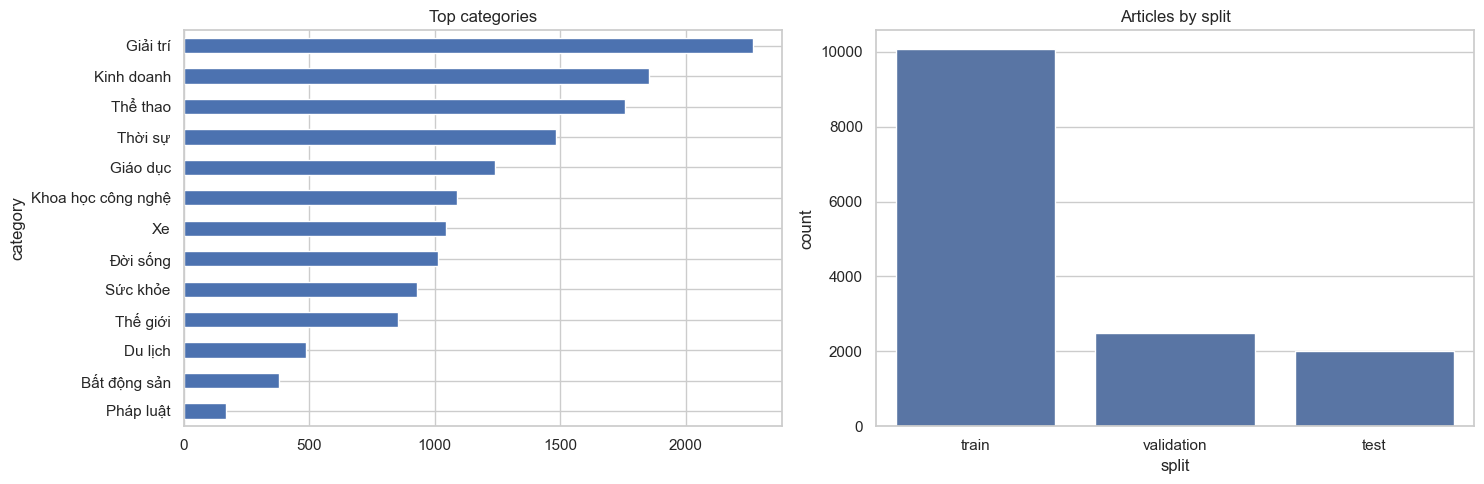

In [2]:
quality=pd.DataFrame({'null_rate':news.isna().mean(),'empty_rate':[(news[c].fillna('').astype(str).str.strip()=='').mean() for c in news.columns]})
display(quality.sort_values('null_rate',ascending=False).head(15).round(4))
print('Duplicate id:',news['id'].duplicated().sum(),'| duplicate title:',news['title'].fillna('').duplicated().sum())
fig,ax=plt.subplots(1,2,figsize=(15,5))
news['category'].fillna('(missing)').value_counts().head(20).sort_values().plot.barh(ax=ax[0],title='Top categories')
sns.countplot(data=news,x='split',ax=ax[1]); ax[1].set_title('Articles by split')
plt.tight_layout()

## Full category distribution
B?ng ??y ?? count v? ph?n tr?m category trong corpus.

In [3]:
category_distribution=news['category'].fillna('(missing)').value_counts().rename_axis('category').reset_index(name='articles')
category_distribution['pct']=(category_distribution['articles']/len(news)*100).round(2)
display(category_distribution)
out=ROOT/'reports'/'eda_outputs'; out.mkdir(parents=True,exist_ok=True)
category_distribution.to_csv(out/'article_category_distribution.csv',index=False)

,category,articles,pct
0,Giải trí,2270,15.58
1,Kinh doanh,1853,12.72
2,Thể thao,1760,12.08
3,Thời sự,1485,10.19
4,Giáo dục,1241,8.52
5,Khoa học công nghệ,1089,7.47
6,Xe,1045,7.17
7,Đời sống,1014,6.96
8,Sức khỏe,928,6.37
9,Thế giới,853,5.85


## Độ dài văn bản và đặc trưng liên quan đến chunking

content_words  sentences  paragraphs
split                                                
test       0.50          611.0       23.0      2787.5
           0.90         1123.2       46.0      5183.9
           0.99         1769.1       82.0      7944.9
train      0.50          606.0       23.0      2788.0
           0.90         1127.8       47.0      5189.8
           0.99         1848.0       85.0      8463.2
validation 0.50          596.0       23.0      2753.5
           0.90         1121.1       47.0      5158.7
           0.99         1978.3       84.0      8948.8

,articles,avg_words,avg_chunks_384,p95_chunks_384
category,,,,
Sức khỏe,928,792.98,2.56,5.0
Kinh doanh,1853,768.27,2.52,4.0
Giáo dục,1241,772.11,2.50,5.0
Bất động sản,379,752.84,2.48,3.0
Đời sống,1014,735.34,2.42,4.0
Du lịch,488,748.22,2.42,4.0
Thời sự,1485,711.61,2.34,5.0
Xe,1045,668.18,2.25,4.0
Giải trí,2270,665.37,2.24,4.0


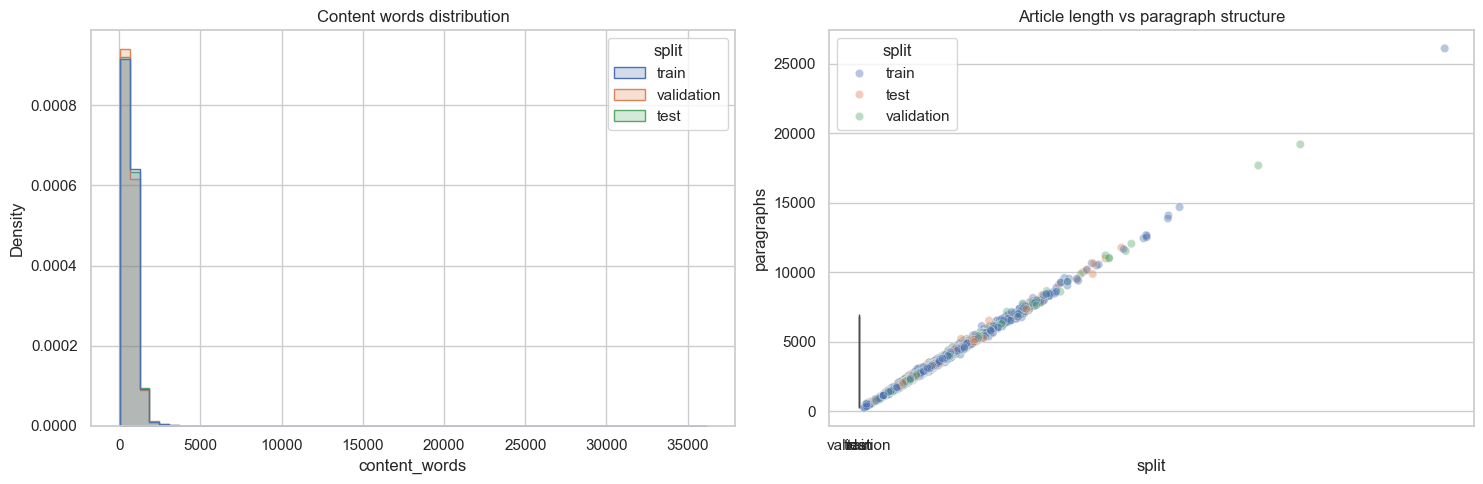

In [4]:
fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.histplot(data=news,x='content_words',hue='split',bins=60,element='step',stat='density',common_norm=False,ax=ax[0]); ax[0].set_title('Content words distribution')
sns.boxplot(data=news,x='split',y='paragraphs',showfliers=False,ax=ax[1]); ax[1].set_title('Paragraphs per article')
plt.tight_layout()
display(news.groupby('split')[['content_words','sentences','paragraphs']].quantile([.5,.9,.99]).round(1))
display(news.groupby('category').agg(articles=('id','size'),avg_words=('content_words','mean'),avg_chunks_384=('est_chunks_384','mean'),p95_chunks_384=('est_chunks_384',lambda s:s.quantile(.95))).sort_values('avg_chunks_384',ascending=False).head(20).round(2))
sns.scatterplot(data=news.sample(min(len(news),5000),random_state=42),x='content_words',y='paragraphs',hue='split',alpha=.4); plt.title('Article length vs paragraph structure'); plt.tight_layout()

## Outliers và export feature table

In [5]:
display(news.nlargest(10,'content_words')[['id','title','category','content_words','paragraphs']])
display(news.nsmallest(10,'content_words')[['id','title','category','content_words','paragraphs']])
out=ROOT/'reports'/'eda_outputs'; out.mkdir(parents=True,exist_ok=True)
cols=['id','split','category','content_chars','content_words','sentences','paragraphs','est_chunks_256','est_chunks_384','est_chunks_512']
news[cols].to_csv(out/'corpus_rag_features.csv',index=False)
print('Saved:',out/'corpus_rag_features.csv')

,id,title,category,content_words,paragraphs
7917,43068,Những mùa mưa đợi chờ - Kỳ cuối: Mưa giăng đồn...,Thời sự,36122,163372
2653,4473,Gợi ý bài giải môn văn thi lớp 10 tại TP.HCM,Giáo dục,11740,53642
613,23558,Bỏ thuế khoán: Nhà nước phải hỗ trợ rất lớn để...,Kinh doanh,5681,26091
11405,247283,"Tên gọi, nơi đặt trụ sở 129 xã, phường của tỉn...",Thời sự,4281,19187
10498,78857,Gỡ 'nút thắt' visa để du lịch tăng tốc,Du lịch,3874,17670
8539,116190,Top 10 kem chống nắng sau sinh bảo vệ da mà kh...,Sức khỏe,3742,17544
11562,116823,"Top 10 kem dưỡng ẩm cho da khô căng mịn, cân c...",Sức khỏe,3512,16506
1985,117085,Top 10 sữa rửa mặt cho da nhạy cảm sạch sâu mà...,Sức khỏe,3503,16406
4373,137244,Chủ tịch UBND TP.HCM Phan Văn Mãi: Tiền không ...,Thời sự,3499,15936
1673,116115,Top 10 kem chống nhăn nâng cơ ngăn ngừa chảy x...,Sức khỏe,3482,16425


,id,title,category,content_words,paragraphs
1615,228102,Inter Milan hạ Feyenoord nhờ cặp song sát Thur...,Thể thao,50,267
2790,222599,Lịch thi đấu vòng tứ kết U23 châu Á 2024 mới n...,Thể thao,50,226
7644,229527,MU vinh danh Lisandro Martinez và Garnacho,Thể thao,50,231
9241,222645,Vì sao U23 Việt Nam 'sập bẫy' VAR trong trận t...,Thể thao,50,223
30,165811,"Sao Việt 10/2/2025: Mai Phương Thuý xinh đẹp, ...",Giải trí,53,263
3630,166792,Các ‘Anh trai vượt ngàn chông gai’ tặng vợ biệ...,Giải trí,53,247
9383,164103,NSND Thanh Ngoan được chồng trẻ kém 7 tuổi yêu...,Giải trí,53,252
13170,229224,Bayern Munich thắng 9-2 ở Champions League,Thể thao,53,271
1798,232452,Kết quả bóng đá Pháp 1-0 Hy Lạp - Vòng loại Eu...,Thể thao,54,440
344,236685,Cầu thủ U22 Việt Nam tiết lộ lời khuyên đặc bi...,Thể thao,55,255


Saved: C:\Khai thác dữ liệu văn bản\Text-Mining---RAG-on-News\reports\eda_outputs\corpus_rag_features.csv
